# Data Exploration

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme()

In [4]:
raw_data = pd.read_parquet("data/processed/category_daily_raw.parquet")
raw_data.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [5]:
daily_sales = raw_data.groupby('ds', observed=True).agg({'y': 'sum'})
daily_sales.head()

,y
ds,
2011-01-29,32631.0
2011-01-30,31749.0
2011-01-31,23783.0
2011-02-01,25412.0
2011-02-02,19146.0


Text(0, 0.5, 'unist Sold')

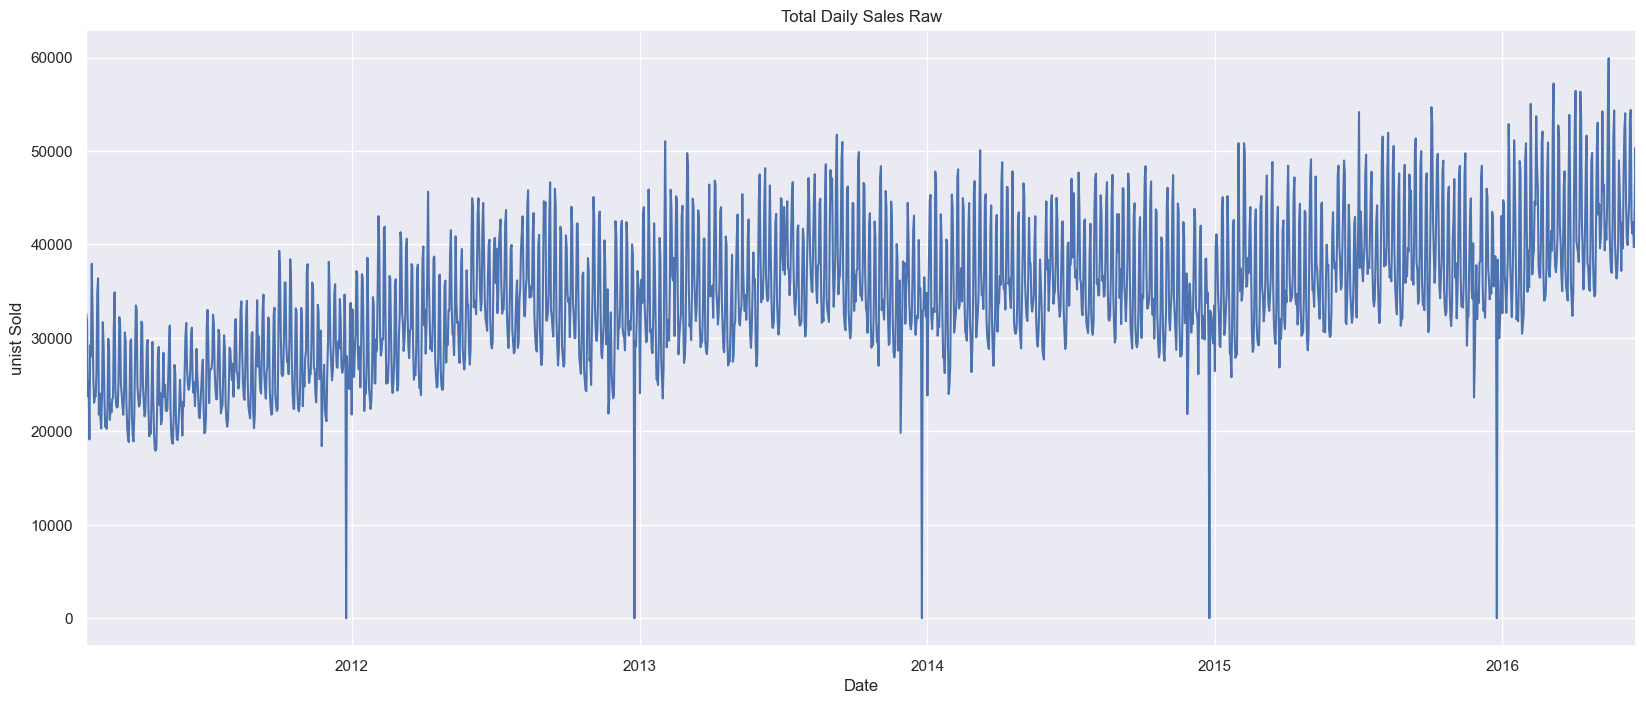

In [58]:
daily_sales.plot(legend=False, figsize=(20,8))
plt.title("Total Daily Sales Raw")
plt.xlabel('Date')
plt.ylabel("unist Sold")

In [7]:
raw_data.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [8]:
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

In [9]:
christmas_mask = (
    raw_data['event_name_1'].str.contains('christmas', case=False, na=False)
    | raw_data['event_name_2'].str.contains('christmas', case=False, na=False)
)

christmas_mask.sum()

np.int64(249014)

In [10]:
event_names = pd.unique(
    raw_data[['event_name_1', 'event_name_2']].values.ravel()
)

event_names

array(['nan', 'SuperBowl', 'ValentinesDay', 'PresidentsDay', 'LentStart',
       'LentWeek2', 'StPatricksDay', 'Purim End', 'OrthodoxEaster',
       'Easter', 'Pesach End', 'Cinco De Mayo', "Mother's day",
       'MemorialDay', 'NBAFinalsStart', 'NBAFinalsEnd', "Father's day",
       'IndependenceDay', 'Ramadan starts', 'Eid al-Fitr', 'LaborDay',
       'ColumbusDay', 'Halloween', 'EidAlAdha', 'VeteransDay',
       'Thanksgiving', 'Christmas', 'Chanukah End', 'NewYear',
       'OrthodoxChristmas', 'MartinLutherKingDay'], dtype=object)

In [11]:
daily_sales[daily_sales['y']<150]

,y
ds,
2011-12-25,13.0
2012-12-25,11.0
2013-12-25,20.0
2014-12-25,20.0
2015-12-25,14.0


In [81]:
raw_data.loc[
    christmas_mask,
    ['ds', 'event_name_1', 'event_name_2','y']
]

,ds,event_name_1,event_name_2,y
330,2011-12-25,Christmas,nan,0.0
343,2012-01-07,OrthodoxChristmas,nan,1.0
696,2012-12-25,Christmas,nan,0.0
709,2013-01-07,OrthodoxChristmas,nan,0.0
1061,2013-12-25,Christmas,nan,0.0
...,...,...,...,...
47649045,2014-01-07,OrthodoxChristmas,nan,0.0
47649397,2014-12-25,Christmas,nan,0.0
47649410,2015-01-07,OrthodoxChristmas,nan,0.0
47649762,2015-12-25,Christmas,nan,0.0


## Build the core category-level views

We keep three related category-level tables throughout the notebook:

- `category_daily_raw`: the source-of-truth category-day sales table with all dates retained
- `category_daily_event_enriched`: the same sales totals enriched with event and calendar flags for diagnostics
- `category_daily_normalized`: a diagnostic-only view that excludes December 25 so one extreme holiday does not dominate certain charts

Important: December 25 is **not** deleted from the raw data. It stays in the raw and event-aware views. It is only excluded from the normalized diagnostic view.


In [33]:
# Set raw data by category
category_daily_raw = (
    raw_data
    .groupby(["ds", "cat_id",], as_index=False, observed=True)
    .agg(y=("y", "sum"))
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)
category_daily_raw.head()

,ds,cat_id,y
0,2011-01-29,HOBBIES,3764.0
1,2011-01-30,HOBBIES,3357.0
2,2011-01-31,HOBBIES,2682.0
3,2011-02-01,HOBBIES,2669.0
4,2011-02-02,HOBBIES,1814.0


In [34]:
calendar_daily = (
    raw_data[
        [
            "ds",
            "event_name_1",
            "event_type_1",
            "event_name_2",
            "event_type_2",
        ]
    ]
    .drop_duplicates(subset="ds")
)

In [35]:
# Add event information to the raw data without excluding any observations
category_daily_event_enriched = category_daily_raw.merge(
    calendar_daily,
    on="ds",
    how="left"
)
category_daily_event_enriched.head()

,ds,cat_id,y,event_name_1,event_type_1,event_name_2,event_type_2
0,2011-01-29,HOBBIES,3764.0,nan,nan,nan,nan
1,2011-01-30,HOBBIES,3357.0,nan,nan,nan,nan
2,2011-01-31,HOBBIES,2682.0,nan,nan,nan,nan
3,2011-02-01,HOBBIES,2669.0,nan,nan,nan,nan
4,2011-02-02,HOBBIES,1814.0,nan,nan,nan,nan


In [83]:
category_daily_event_enriched.loc[
    christmas_mask,
    ['ds', 'event_name_1', 'event_name_2','y']
]

,ds,event_name_1,event_name_2,y
330,2011-12-25,Christmas,nan,0.0
343,2012-01-07,OrthodoxChristmas,nan,3468.0
696,2012-12-25,Christmas,nan,0.0
709,2013-01-07,OrthodoxChristmas,nan,2000.0
1061,2013-12-25,Christmas,nan,0.0
1074,2014-01-07,OrthodoxChristmas,nan,2845.0
1426,2014-12-25,Christmas,nan,0.0
1439,2015-01-07,OrthodoxChristmas,nan,2559.0
1791,2015-12-25,Christmas,nan,0.0
1804,2016-01-07,OrthodoxChristmas,nan,3327.0


In [36]:
# Identify Christmas for the normalized diagnostic dataset
category_daily_event_enriched["is_christmas"] = (
    category_daily_event_enriched["event_name_1"].eq("Christmas")
    | category_daily_event_enriched["event_name_2"].eq("Christmas")
)

# Excluding Christmas sales creates the normalized diagnostic dataset
category_daily_normalized = category_daily_event_enriched.loc[
    ~category_daily_event_enriched["is_christmas"]
].copy()

category_daily_normalized.head()


,ds,cat_id,y,event_name_1,event_type_1,event_name_2,event_type_2,is_christmas
0,2011-01-29,HOBBIES,3764.0,nan,nan,nan,nan,False
1,2011-01-30,HOBBIES,3357.0,nan,nan,nan,nan,False
2,2011-01-31,HOBBIES,2682.0,nan,nan,nan,nan,False
3,2011-02-01,HOBBIES,2669.0,nan,nan,nan,nan,False
4,2011-02-02,HOBBIES,1814.0,nan,nan,nan,nan,False


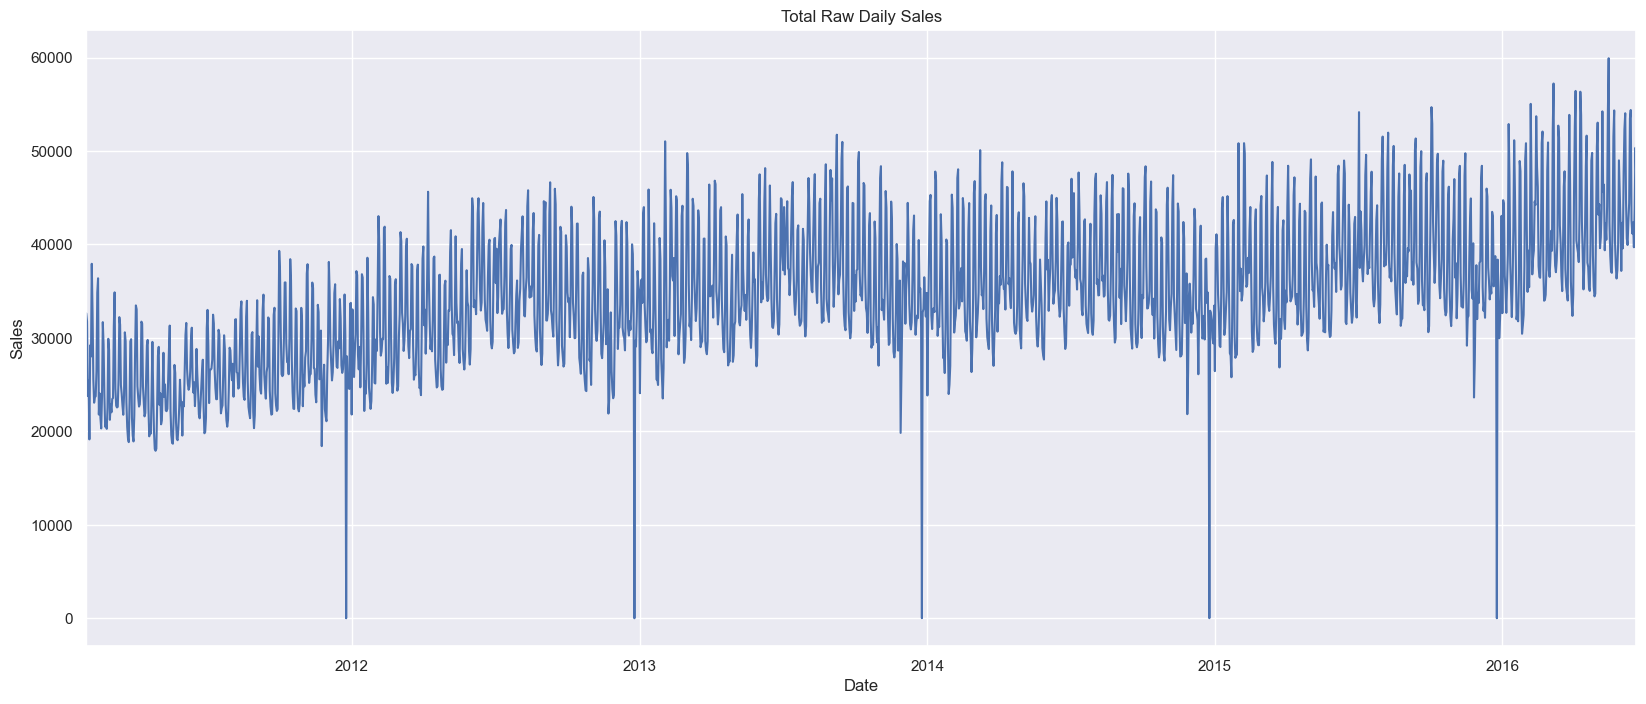

In [59]:
# Compare the raw and normalized views to assess the effect of removing Christmas sales
# Daily Sales with Christmas
daily_sales_with_christmas = (
    category_daily_event_enriched
    .groupby("ds", as_index=False)["y"]
    .sum()
)

daily_sales_with_christmas[['ds', 'y']].plot(x="ds", y="y", figsize=(20,8), legend=False)
plt.title("Total Raw Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


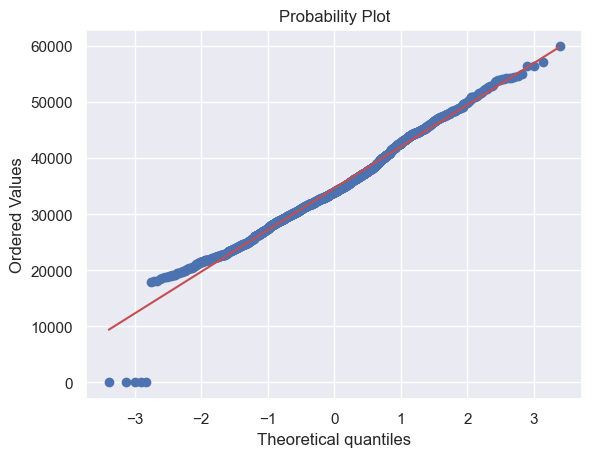

In [84]:
# Distribution diagnostic
stats.probplot(daily_sales_with_christmas["y"], dist="norm", plot=plt);

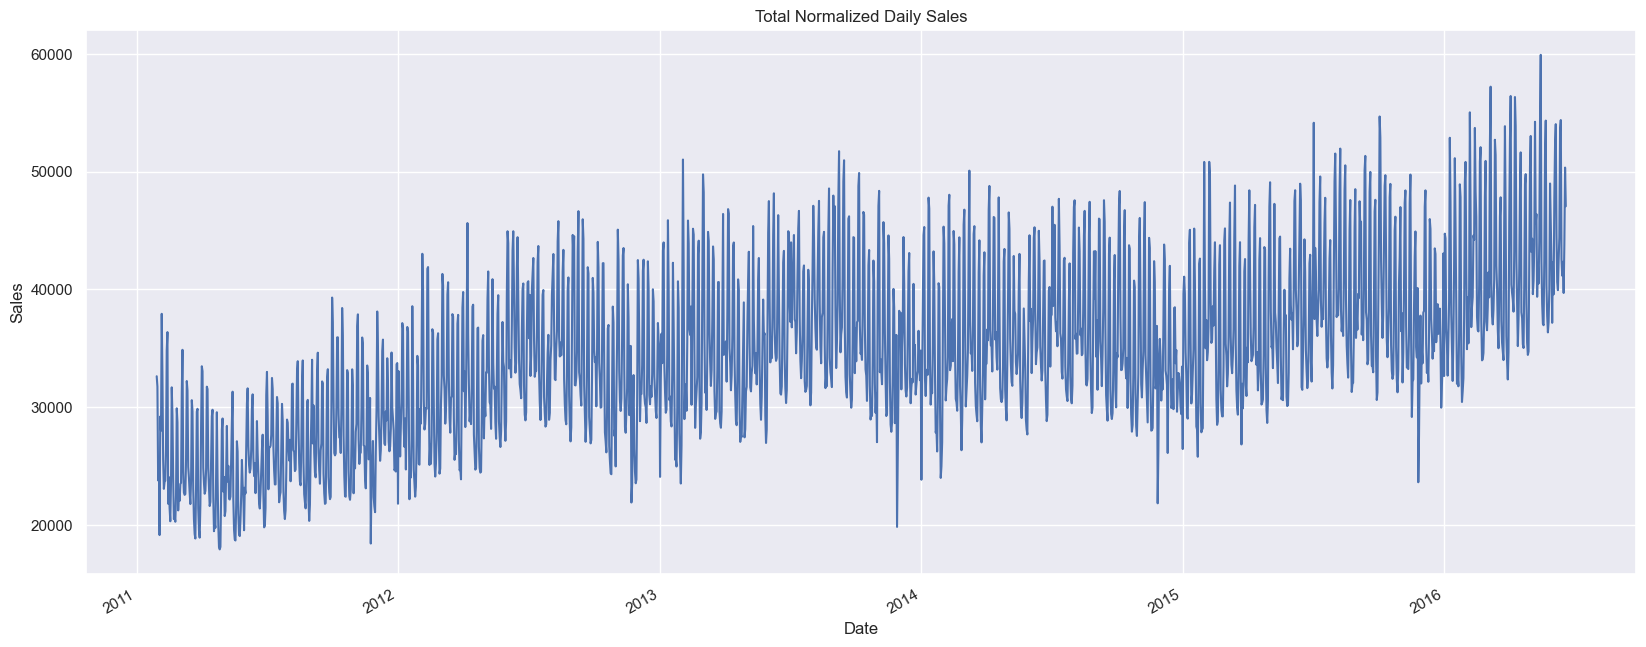

In [60]:
# Normalized dataset all sales
daily_sales_no_christmas = (
    category_daily_normalized
    .groupby("ds", as_index=False)["y"]
    .sum()
)

daily_sales_no_christmas[['ds', 'y']].plot(x="ds", y="y", figsize=(20,8), legend=False)
plt.title("Total Normalized Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


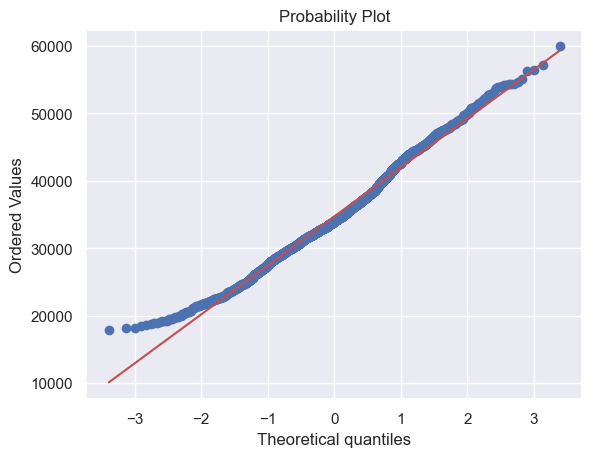

In [85]:
# Distribution diagnostic
stats.probplot(daily_sales_no_christmas["y"], dist="norm", plot=plt);

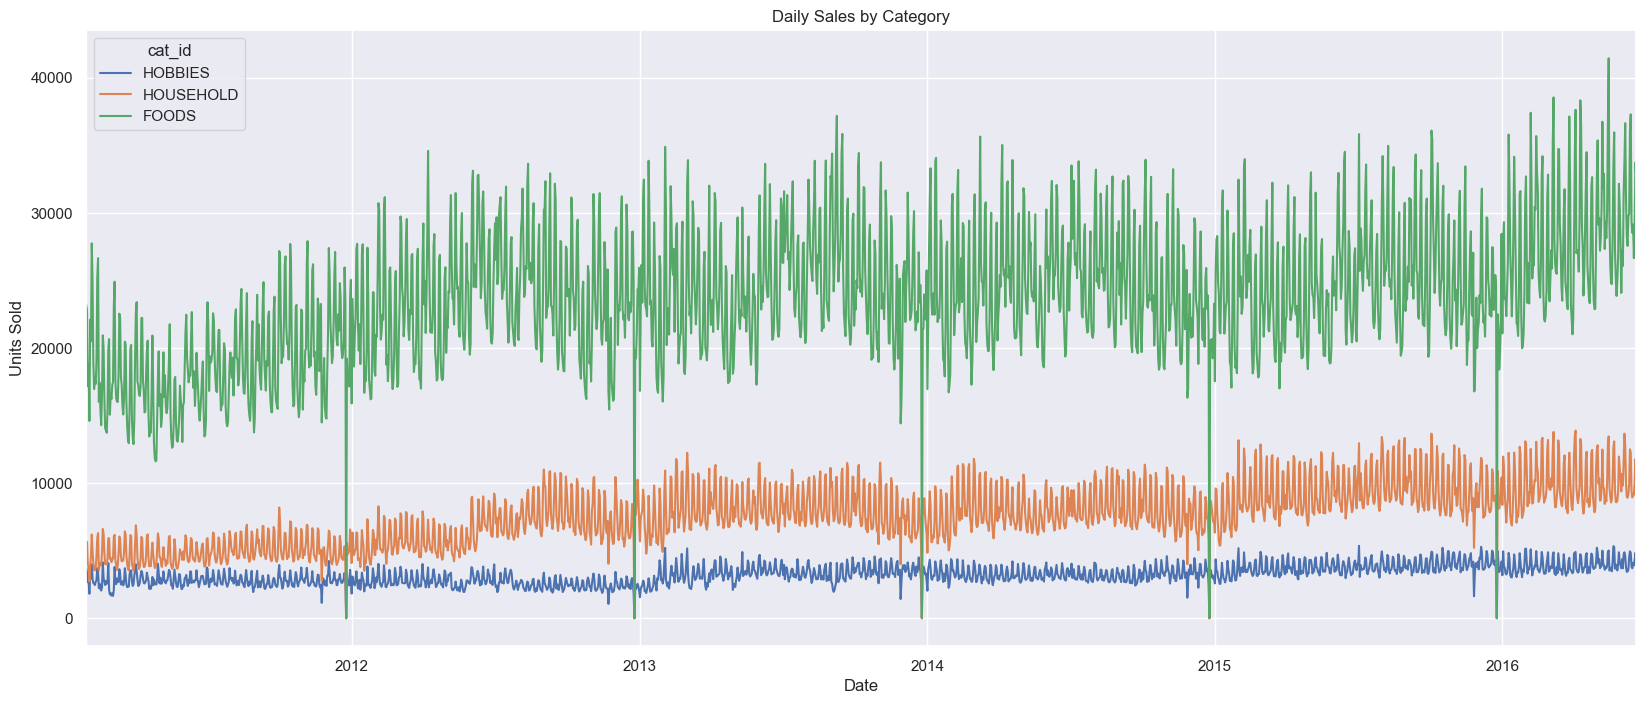

In [61]:
plot_df = (
    category_daily_event_enriched
    .pivot(index="ds", columns="cat_id", values="y")
    .sort_index()
)

plot_df.plot(figsize=(20, 8))

plt.title("Daily Sales by Category")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend(title="cat_id")
plt.show()

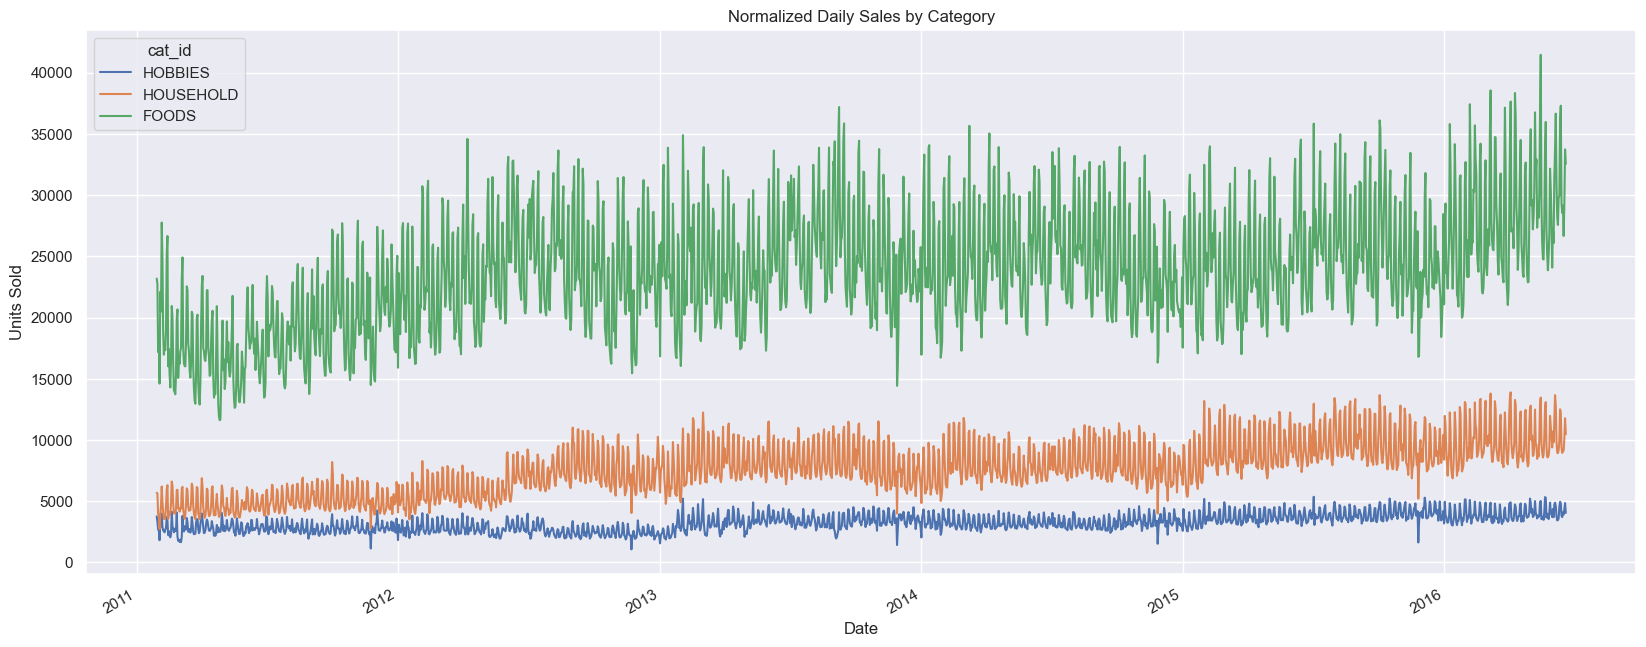

In [62]:
plot_normalized = (
    category_daily_normalized
    .pivot(index="ds", columns="cat_id", values="y")
    .sort_index()
)

plot_normalized.plot(figsize=(20, 8))

plt.title("Normalized Daily Sales by Category")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend(title="cat_id")
plt.show()

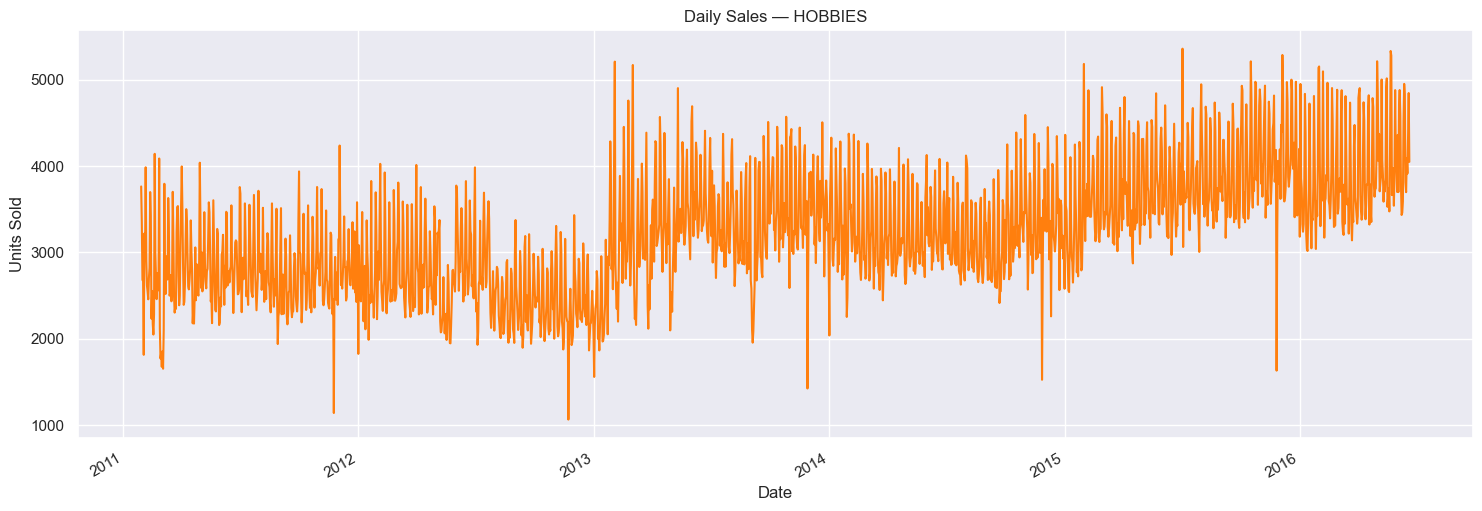

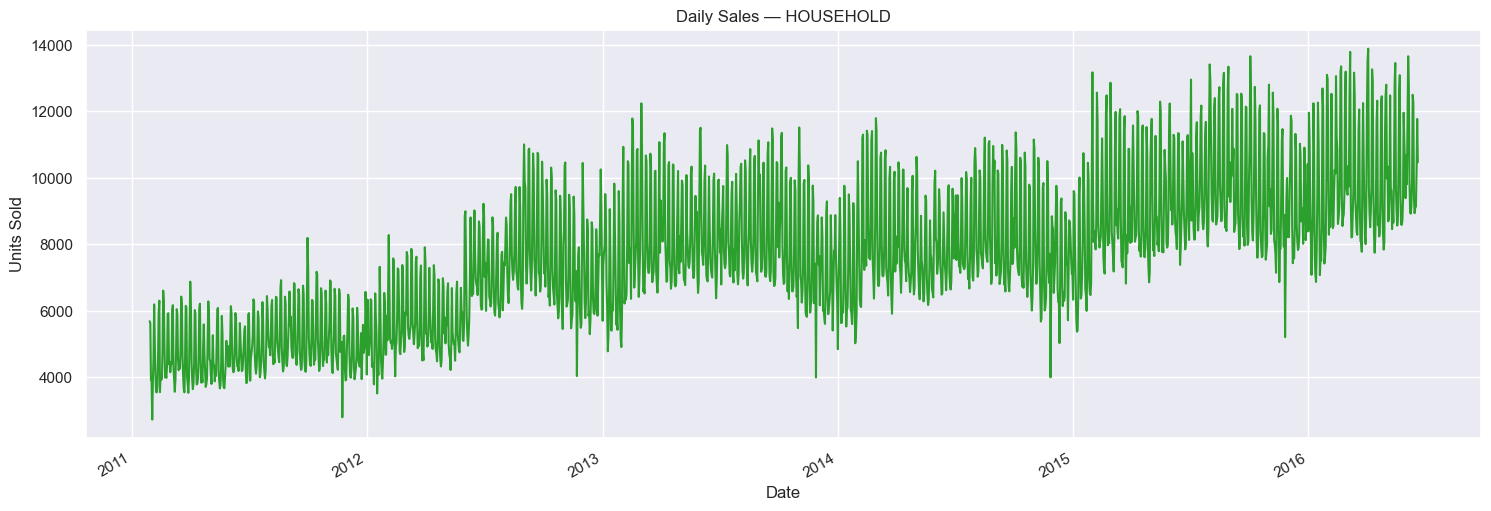

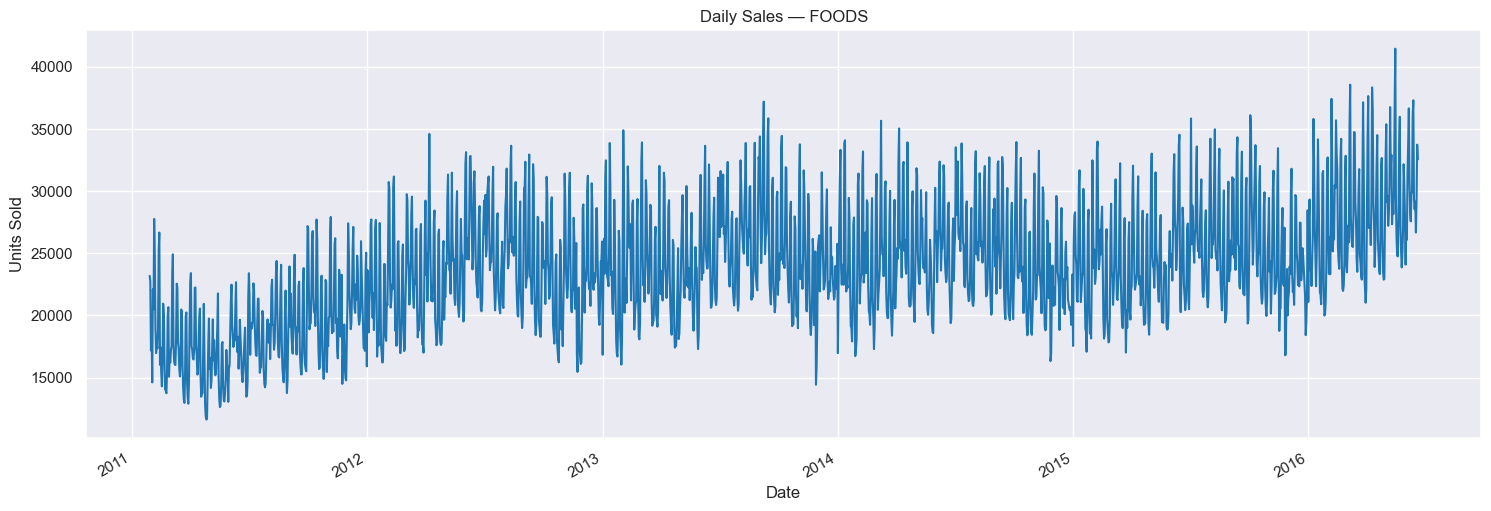

In [63]:
category_colors = {
    "FOODS": "tab:blue",
    "HOUSEHOLD": "tab:green",
    "HOBBIES": "tab:orange"
}

for category in category_daily_normalized["cat_id"].unique():

    category_data = category_daily_normalized[
        category_daily_normalized["cat_id"] == category
    ]

    category_data.plot(
        x="ds",
        y="y",
        figsize=(18, 6),
        color=category_colors[category],
        legend=False
    )

    plt.title(f"Daily Sales — {category}")
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.show()

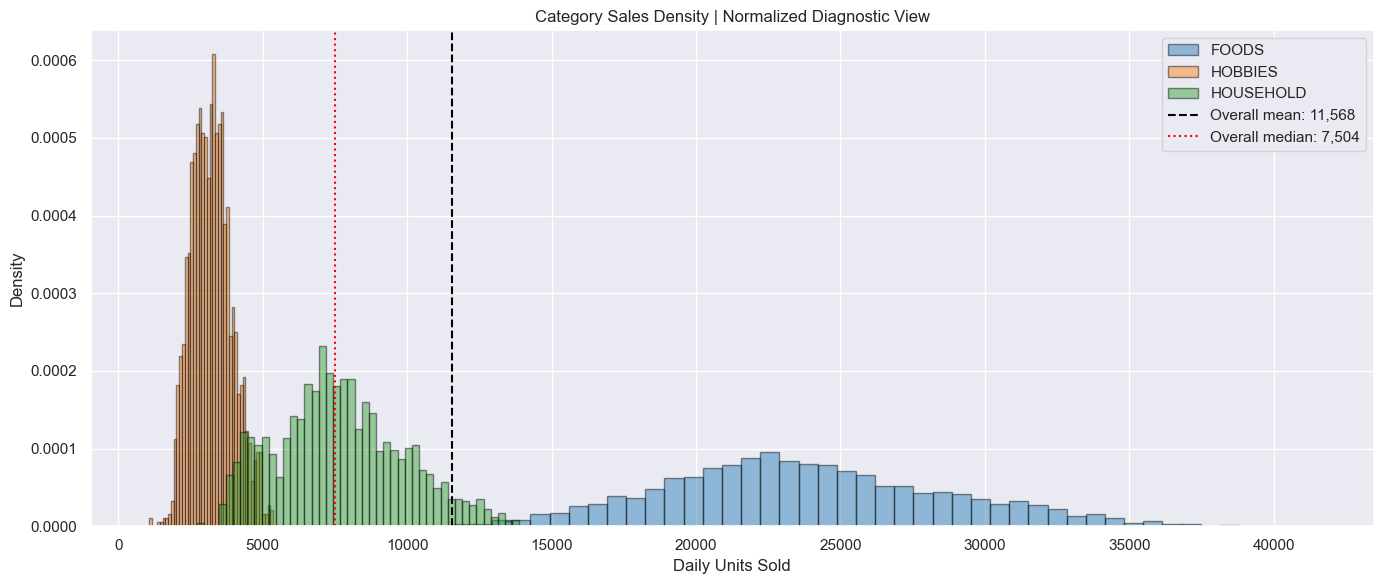

In [64]:
overall_mean = category_daily_normalized["y"].mean()
overall_median = category_daily_normalized["y"].median()

CATEGORY_COLORS = {
    "FOODS": "tab:blue",
    "HOBBIES": "tab:orange",
    "HOUSEHOLD": "tab:green",
}

plt.figure(figsize=(14, 6))

for cat in sorted(category_daily_normalized["cat_id"].unique()):
    data = category_daily_normalized.loc[category_daily_normalized["cat_id"].eq(cat), "y"]
    plt.hist(
        data,
        bins="sqrt",
        density=True,
        alpha=0.45,
        edgecolor="black",
        label=cat,
        color=CATEGORY_COLORS.get(cat, "tab:gray"),
    )

plt.axvline(overall_mean, color="black", linestyle="--", label=f"Overall mean: {overall_mean:,.0f}")
plt.axvline(overall_median, color="red", linestyle=":", label=f"Overall median: {overall_median:,.0f}")
plt.title("Category Sales Density | Normalized Diagnostic View")
plt.xlabel("Daily Units Sold")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [66]:
# Helper to create an individual histogram for each category
def plot_category_histograms(
    df: pd.DataFrame,
    title_suffix: str,
    density: bool = False,
) -> None:
    """Plot one histogram per category with mean and median markers."""

    y_label = "Density" if density else "Frequency"

    for cat in sorted(df["cat_id"].dropna().unique()):
        data = df.loc[df["cat_id"].eq(cat), "y"].dropna()

        mean_sales = data.mean()
        median_sales = data.median()

        fig, ax = plt.subplots(figsize=(12, 4))

        ax.hist(
            data,
            bins="sqrt",
            density=density,
            color=CATEGORY_COLORS.get(cat, "tab:gray"),
            edgecolor="black",
            alpha=0.45,
        )

        ax.axvline(
            mean_sales,
            color="black",
            linestyle="--",
            label=f"Mean: {mean_sales:,.0f}",
        )

        ax.axvline(
            median_sales,
            color="red",
            linestyle=":",
            label=f"Median: {median_sales:,.0f}",
        )

        ax.set_title(f"{cat} Sales Distribution | {title_suffix}")
        ax.set_xlabel("Daily Units Sold")
        ax.set_ylabel(y_label)
        ax.legend()

        plt.tight_layout()
        plt.show()

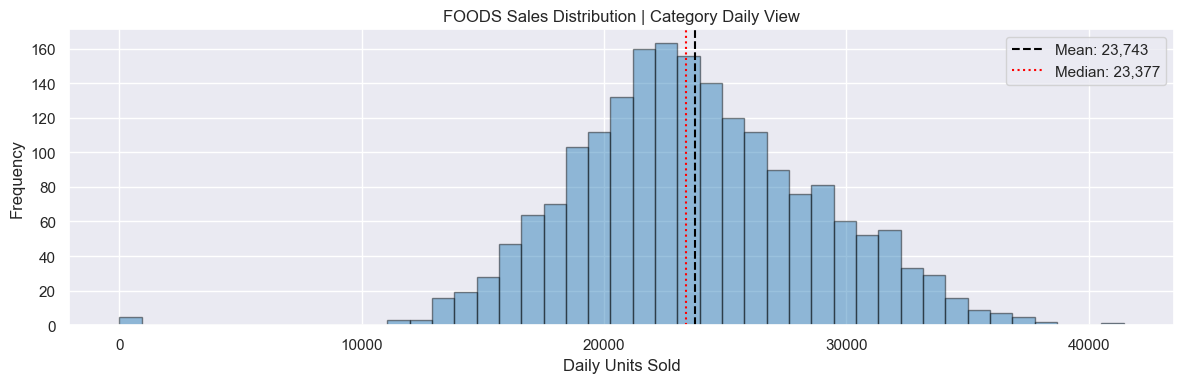

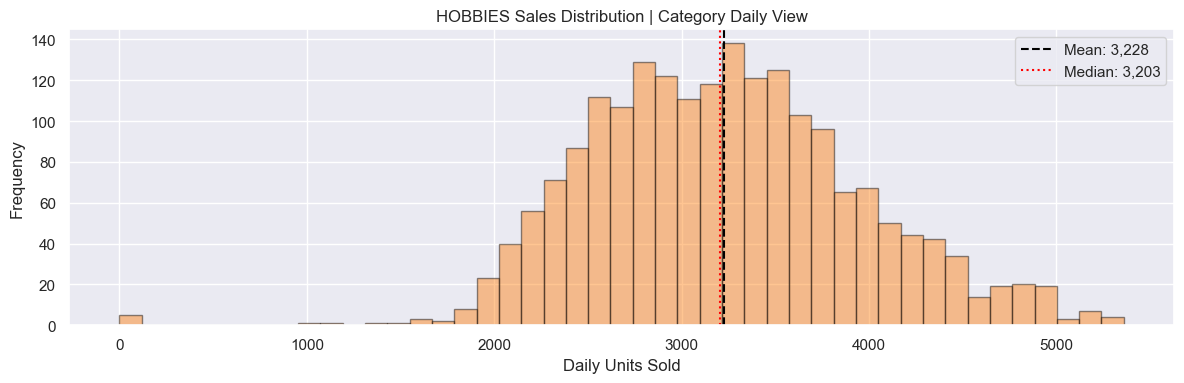

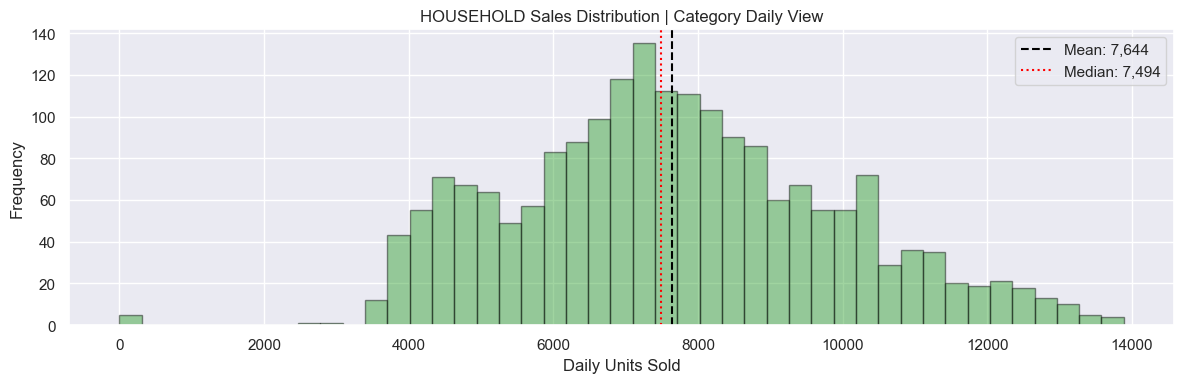

In [70]:
plot_category_histograms(category_daily_event_enriched, title_suffix="Category Daily View", density=False)

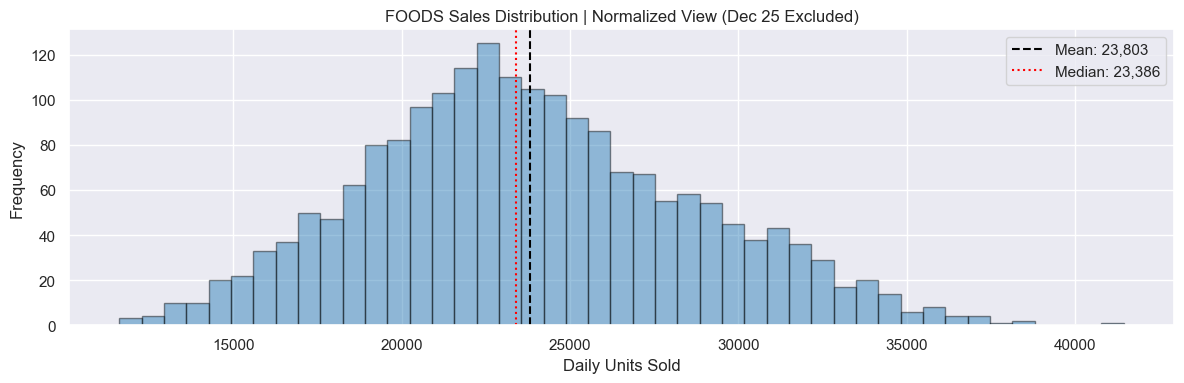

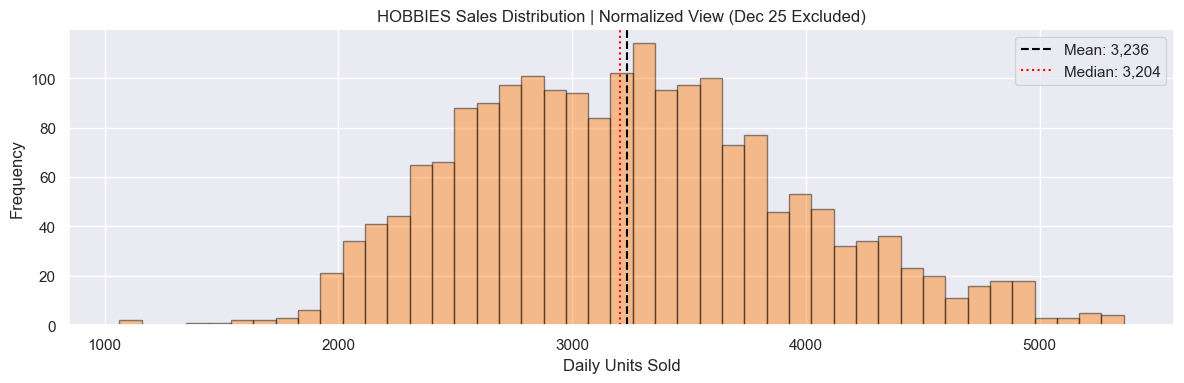

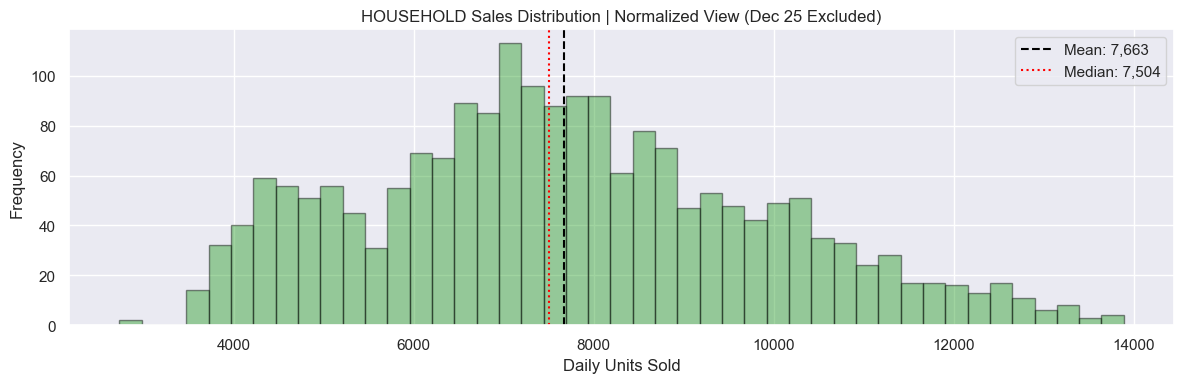

In [67]:
plot_category_histograms(category_daily_normalized, title_suffix="Normalized View (Dec 25 Excluded)", density=False)

In [77]:
# Helper for distribution diagnostics by category
def qq_plots_by_category(data, col="y", title="QQ Plot"):
    for category in sorted(data["cat_id"].dropna().unique()):

        values = (
            data.loc[data["cat_id"].eq(category), col]
            .dropna()
        )

        plt.figure(figsize=(6, 6))

        stats.probplot(
            values,
            dist="norm",
            plot=plt
        )

        plt.title(f"{title} — {category}")
        plt.xlabel("Theoretical Quantiles")
        plt.ylabel("Ordered Daily Sales")
        plt.tight_layout()
        plt.show()

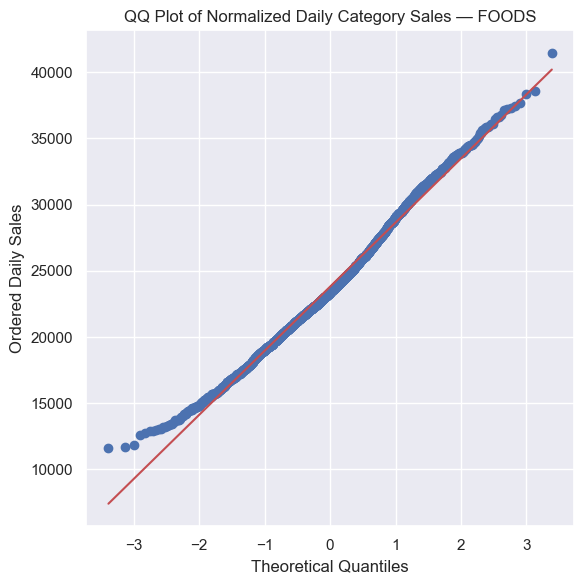

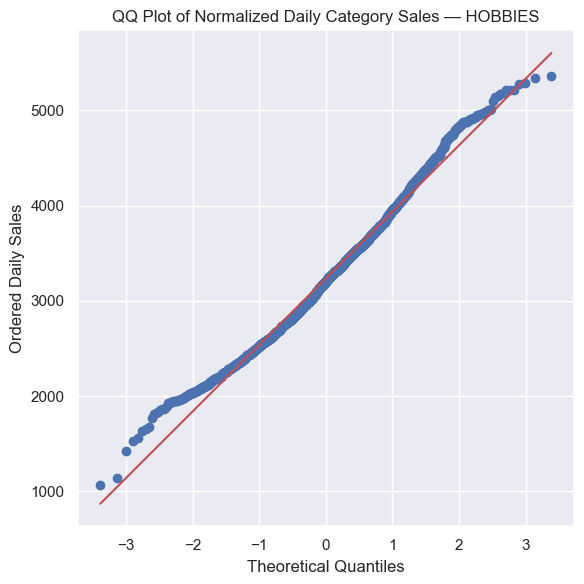

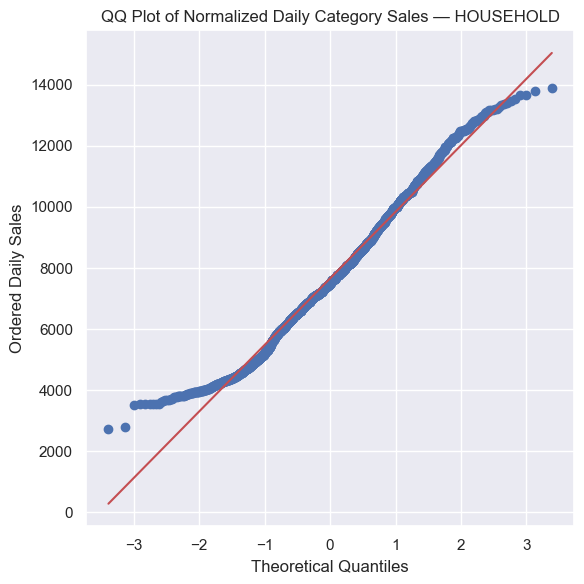

In [79]:
qq_plots_by_category(
    category_daily_normalized,
    col="y",
    title="QQ Plot of Normalized Daily Category Sales"
)

In [87]:
# Use this helper to group by month and week and inspect patterns throughout the year.
# the months, and event he day of the wek and see if that may have some useful help on the future
def add_calendar_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Add simple reusable calendar flags for time-series EDA."""

    out = df.copy()
    out["year"] = out["ds"].dt.year
    out["month"] = out["ds"].dt.month
    out["day"] = out["ds"].dt.day
    out["dayofweek"] = out["ds"].dt.day_name()
    out["weekofyear"] = out["ds"].dt.isocalendar().week.astype(int)
    out["is_christmas"] = out["month"].eq(12) & out["day"].eq(25)
    out["is_christmas_eve"] = out["month"].eq(12) & out["day"].eq(24)
    out["is_day_after_christmas"] = out["month"].eq(12) & out["day"].eq(26)
    out["is_new_years_day"] = out["month"].eq(1) & out["day"].eq(1)
    out["is_thanksgiving_window"] = out["month"].eq(11) & out["day"].between(22, 28)
    return out

In [88]:
seasonality_df = add_calendar_flags(category_daily_raw)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

category_dow_sales = (
    seasonality_df
    .groupby(["cat_id", "dayofweek"], observed=True)["y"]
    .mean()
    .reset_index()
)
category_dow_sales["dayofweek"] = pd.Categorical(
    category_dow_sales["dayofweek"],
    categories=weekday_order,
    ordered=True,
)
category_dow_sales = category_dow_sales.sort_values(["cat_id", "dayofweek"])

category_dow_sales

,cat_id,dayofweek,y
1,HOBBIES,Monday,3004.021240
5,HOBBIES,Tuesday,2874.975098
6,HOBBIES,Wednesday,2907.932373
4,HOBBIES,Thursday,2902.508789
0,HOBBIES,Friday,3348.491211
2,HOBBIES,Saturday,3960.684326
3,HOBBIES,Sunday,3593.627686
8,HOUSEHOLD,Monday,7209.740234
12,HOUSEHOLD,Tuesday,6576.711914
13,HOUSEHOLD,Wednesday,6501.071289


In [94]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

category_month_sales = (
    seasonality_df
    .groupby(["cat_id", "month"], observed=True, as_index=False)
    .agg(y=("y", "mean"))
)

category_month_sales["month"] = pd.Categorical(
    category_month_sales["month"],
    categories=month_order,
    ordered=True,
)

category_month_sales = category_month_sales.sort_values(
    ["cat_id", "month"]
)

In [96]:
def plot_category_bar_panels(
    data,
    x_col,
    y_col,
    title_prefix,
    xlabel,
    ylabel,
    rotation=0,
):
    """Create one bar chart for each category."""

    categories = sorted(data["cat_id"].dropna().unique())

    fig, axes = plt.subplots(
        nrows=len(categories),
        ncols=1,
        figsize=(14, 4 * len(categories)),
    )

    # Ensures axes is iterable even when there is only one category
    axes = np.atleast_1d(axes)

    for ax, category in zip(axes, categories):

        category_data = data.loc[
            data["cat_id"].eq(category)
        ].copy()

        ax.bar(
            category_data[x_col],
            category_data[y_col],
            color=CATEGORY_COLORS.get(category, "tab:gray"),
            edgecolor="black",
            alpha=0.75,
        )

        ax.set_title(f"{title_prefix} — {category}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=rotation)

    plt.tight_layout()
    plt.show()

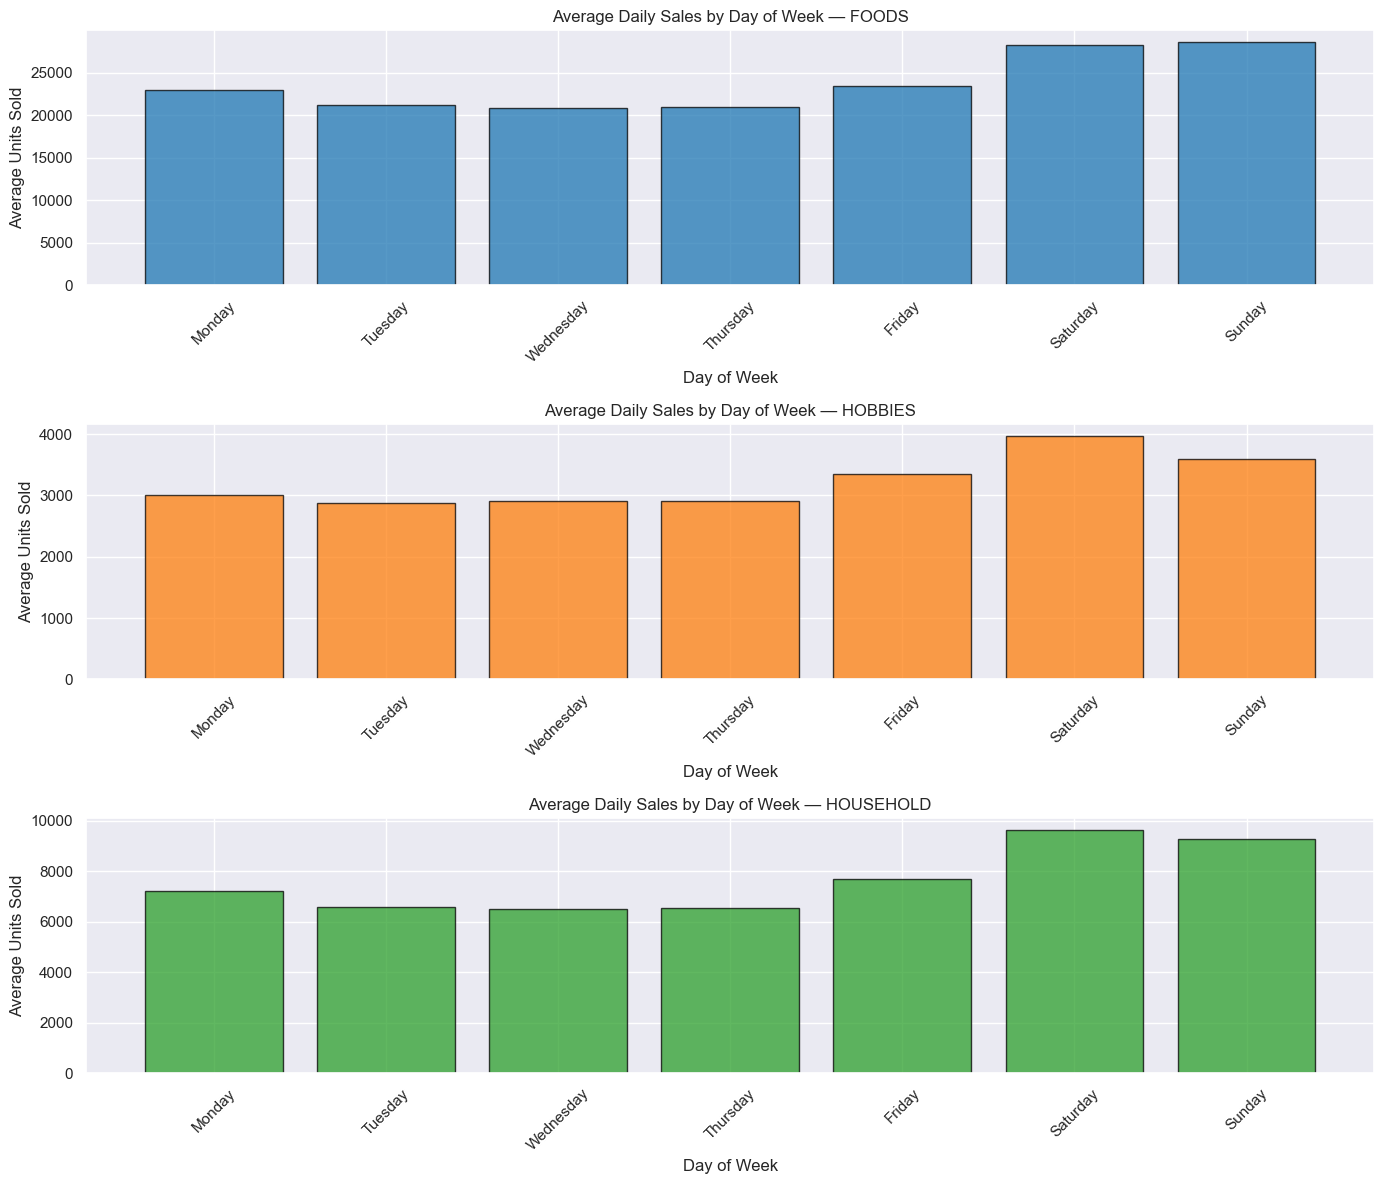

In [90]:
plot_category_bar_panels(
    category_dow_sales,
    x_col="dayofweek",
    y_col="y",
    title_prefix="Average Daily Sales by Day of Week",
    xlabel="Day of Week",
    ylabel="Average Units Sold",
    rotation=45,
)

In [104]:
seasonality_df = add_calendar_flags(category_daily_raw)

seasonality_df["week"] = seasonality_df["ds"].dt.isocalendar().week

category_week_sales = (
    seasonality_df
    .groupby(["cat_id", "week"], observed=True, as_index=False)
    .agg(y=("y", "mean"))
    .sort_values(["cat_id", "week"])
)
category_week_sales

,cat_id,week,y
0,HOBBIES,1,3124.657227
1,HOBBIES,2,2994.171387
2,HOBBIES,3,3062.885742
3,HOBBIES,4,3312.486572
4,HOBBIES,5,3349.476074
...,...,...,...
154,FOODS,49,24482.914062
155,FOODS,50,23980.285156
156,FOODS,51,22645.257812
157,FOODS,52,19365.115234


In [105]:
def plot_category_line_panels(
    data,
    x_col,
    y_col,
    title_prefix,
    xlabel,
    ylabel,
):
    categories = sorted(data["cat_id"].dropna().unique())

    fig, axes = plt.subplots(
        nrows=len(categories),
        ncols=1,
        figsize=(14, 4 * len(categories)),
    )

    axes = np.atleast_1d(axes)

    for ax, category in zip(axes, categories):
        category_data = data.loc[
            data["cat_id"].eq(category)
        ].sort_values(x_col)

        ax.plot(
            category_data[x_col],
            category_data[y_col],
            color=CATEGORY_COLORS.get(category, "tab:gray"),
        )

        ax.set_title(f"{title_prefix} — {category}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

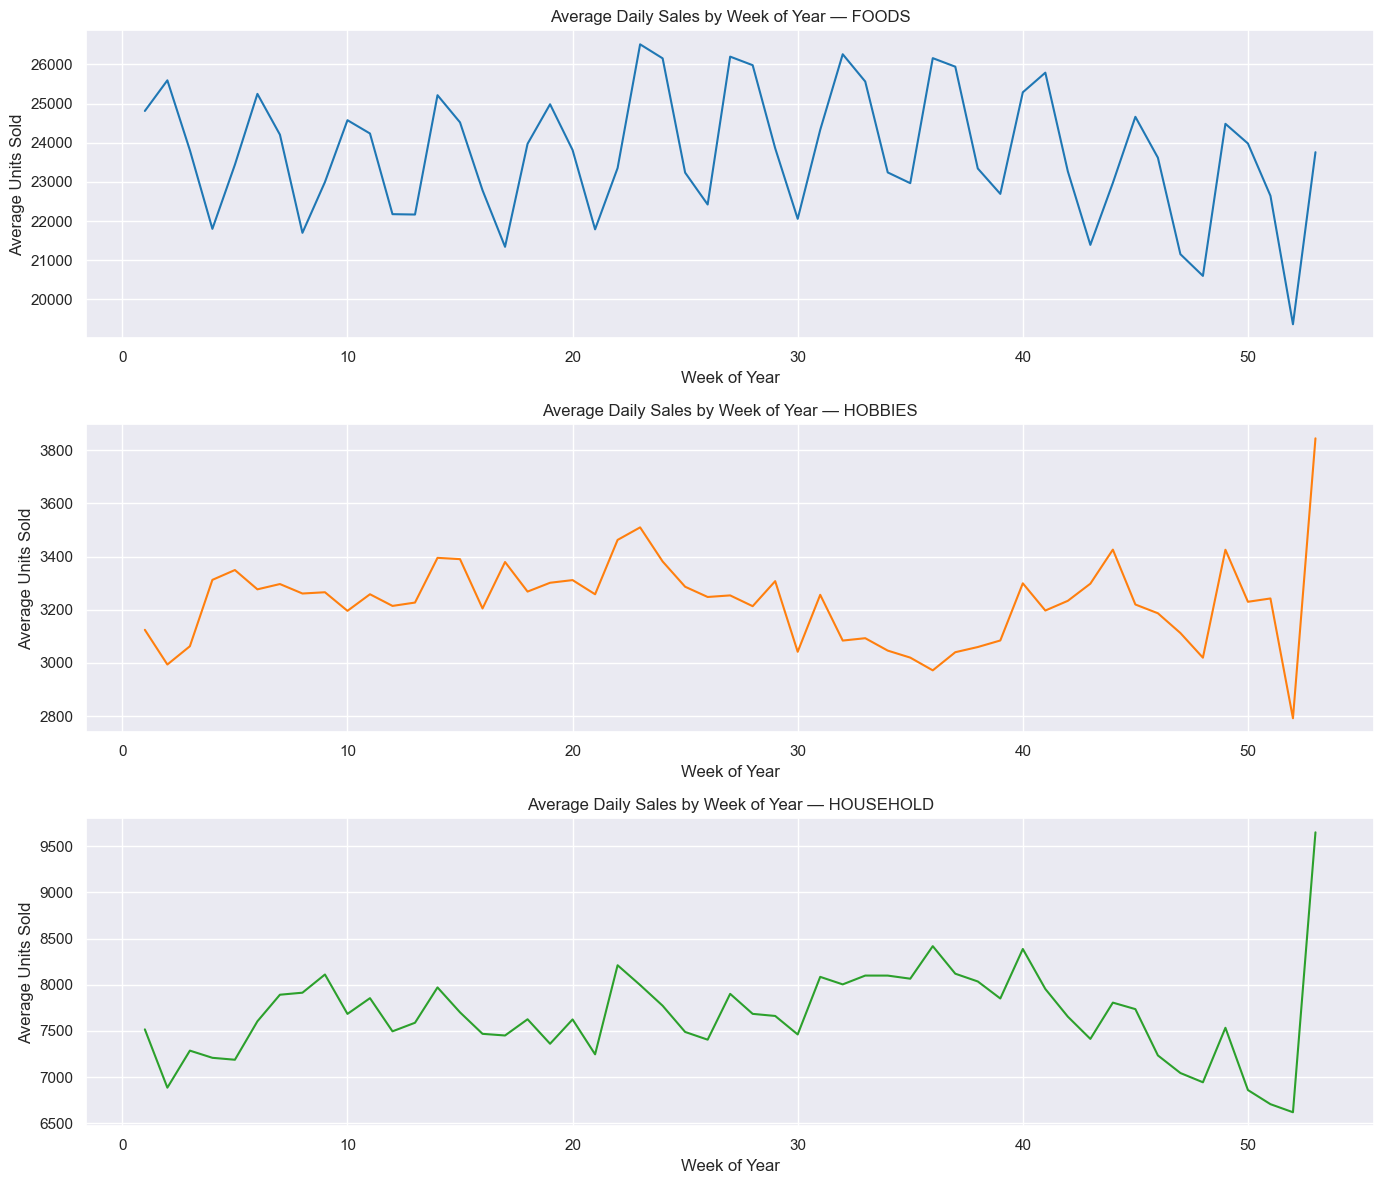

In [106]:
plot_category_line_panels(
    category_week_sales,
    x_col="week",
    y_col="y",
    title_prefix="Average Daily Sales by Week of Year",
    xlabel="Week of Year",
    ylabel="Average Units Sold",
)

In [101]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Create month names if add_calendar_flags did not already create them
seasonality_df["month"] = seasonality_df["ds"].dt.month_name()

# Average daily sales for each category and month
category_month_sales = (
    seasonality_df
    .groupby(
        ["cat_id", "month"],
        observed=True,
        as_index=False
    )
    .agg(y=("y", "mean"))
)

# Put months in calendar order
category_month_sales["month"] = pd.Categorical(
    category_month_sales["month"],
    categories=month_order,
    ordered=True,
)

category_month_sales = category_month_sales.sort_values(
    ["cat_id", "month"]
)

category_month_sales.head()

,cat_id,month,y
4,HOBBIES,January,3137.917725
3,HOBBIES,February,3289.094238
7,HOBBIES,March,3220.096680
0,HOBBIES,April,3336.633301
8,HOBBIES,May,3316.741943


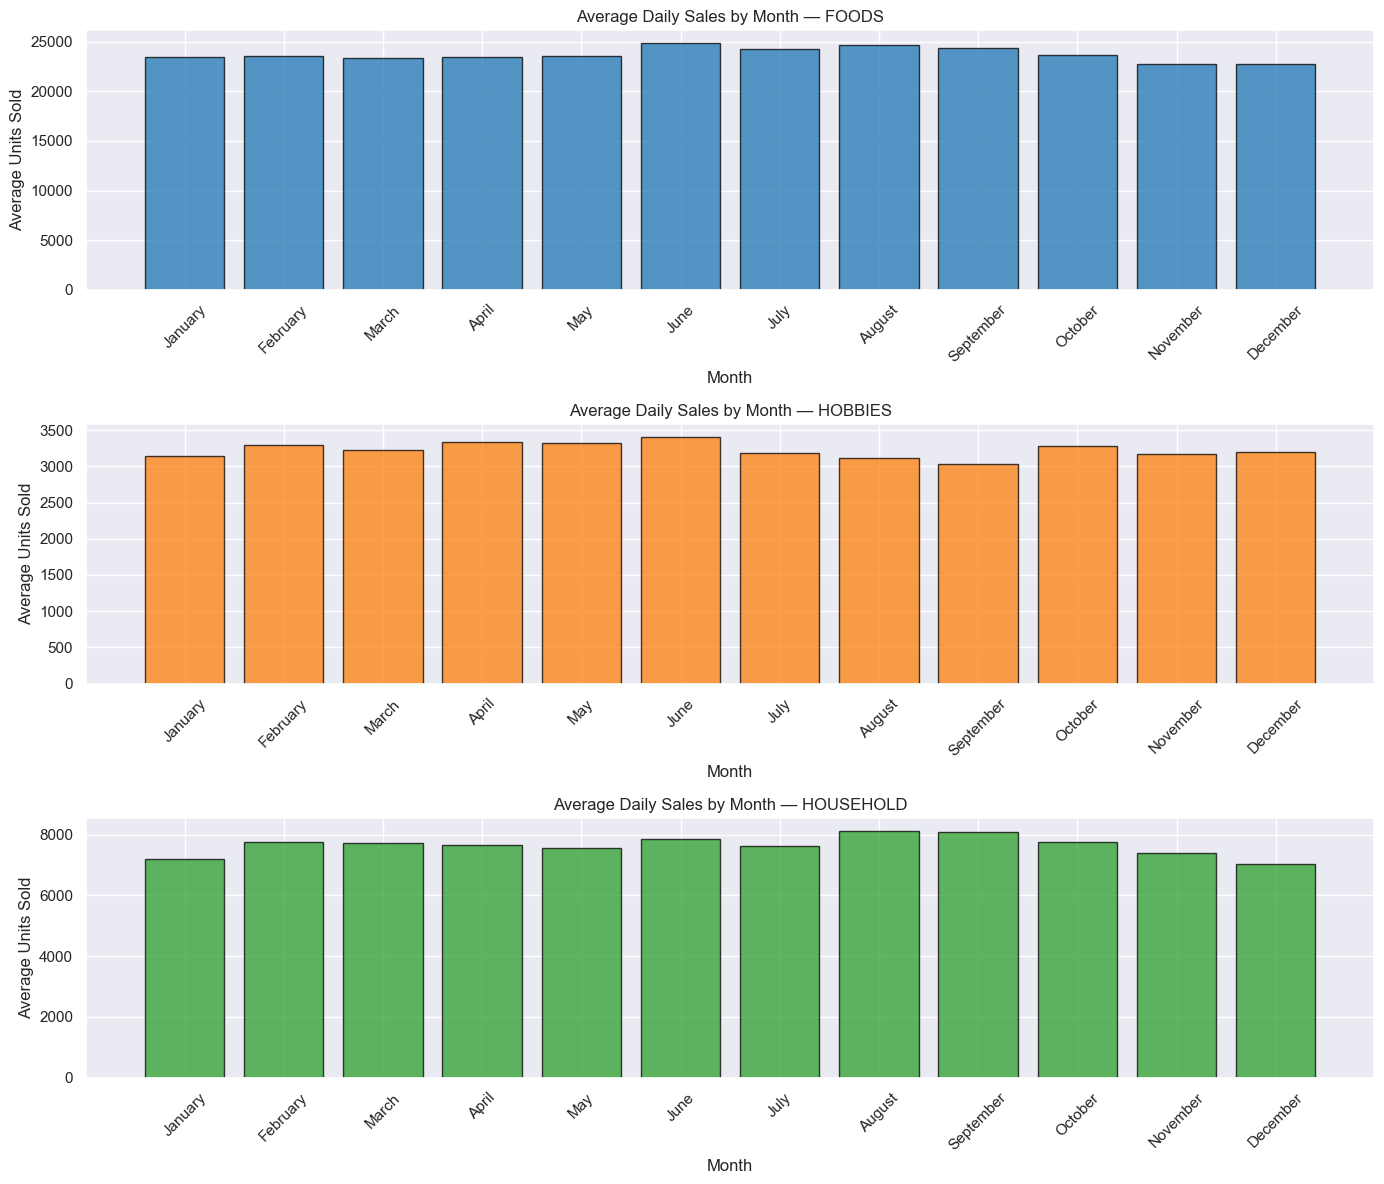

In [102]:
plot_category_bar_panels(
    category_month_sales,
    x_col="month",
    y_col="y",
    title_prefix="Average Daily Sales by Month",
    xlabel="Month",
    ylabel="Average Units Sold",
    rotation=45,
)

In [80]:
category_daily_normalized.to_parquet("data/processed/category_daily_normalized.parquet", index=False)
category_daily_event_enriched.to_parquet("data/processed/category_daily_event_enriched.parquet", index=False)

## EDA Conclusion

The exploratory analysis identified several important demand patterns:

- **Christmas Day consistently drops to zero or near zero**, most likely because of store closures. I therefore created `category_daily_normalized`, a diagnostic-only view that excludes December 25 while preserving the original data. Christmas will later be handled as a known holiday adjustment.
- Removing Christmas produced more representative histograms and QQ plots by reducing the artificial lower tail. **FOODS and HOBBIES are reasonably close to normal**, while **HOUSEHOLD remains slightly right-skewed**.
- **Weekly seasonality is clear across all categories**, with demand generally increasing from Friday through Sunday. This supports using a 7-day seasonal naive forecast as an initial benchmark.
- The categories behave differently:
  - **FOODS** is the most stable.
  - **HOBBIES** shows more variation over time.
  - **HOUSEHOLD** shows the clearest upward movement.
- The week-of-year plots show notable dips around weeks 30 and 51, while June, August, and September are generally strong months. These patterns may reflect seasonal behavior, holidays, or other calendar effects and should be tested further rather than treated as causal conclusions.
- The stronger weekend demand also has an inventory implication: products should ideally be available before the highest-demand period, depending on lead times and delivery schedules.

Overall, the data is prepared for **baseline forecasting** using naive, seasonal naive, moving-average, and exponential-smoothing models. These benchmarks will establish the minimum level of performance that more advanced forecasting models must outperform.